In [2]:
!pip freeze > requirements.txt

In [3]:
import pandas

In [ ]:
df = pandas.read_csv('https://raw.githubusercontent.com/Uwanga14/netflix_customer_churn/refs/heads/main/Model1.csv')

In [5]:
df.head(5)

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day,gender_0,gender_1,gender_2,...,engagement_score,watch_intensity,inactive_customer,multiple_profiles,recency_score,premium_subscriber,low_engagement,high_engagement,shared_account,daily_engagement_ratio
0,51,14,29,8,1,1,0,0,0,1,...,0,0,1,0,0.033333,0,0,0,0,0.00
1,47,0,19,13,1,5,0,0,0,1,...,0,0,1,1,0.050000,0,1,0,1,0.00
2,27,16,10,13,0,2,1,1,0,0,...,16,1,0,1,0.090909,0,0,0,0,0.06
3,53,4,12,17,1,2,0,0,0,1,...,0,0,0,1,0.076923,1,1,0,0,0.00
4,56,1,13,13,1,2,0,0,0,1,...,0,0,0,1,0.071429,0,1,0,0,0.00


In [6]:
selected_features = [
'watch_hours',
'avg_watch_time_per_day',
'last_login_days',
'number_of_profiles',
'engagement_score',
'watch_intensity',
'inactive_customer'
]


In [7]:
# Separate features and target

X = df.drop('churned', axis=1)
y = df['churned']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 45)
Target shape: (5000,)


In [8]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

churned
1    2515
0    2485
Name: count, dtype: int64
churned
1    50.3
0    49.7
Name: proportion, dtype: float64


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
#Check the size of each split
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("Training set:", y_train.shape)
print("Testing set:", y_test.shape)

Training set: (4000, 45)
Testing set: (1000, 45)
Training set: (4000,)
Testing set: (1000,)


In [11]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
n_estimators=200,
max_depth=10,
min_samples_split=5,
random_state=42
)
 
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

A Random Forest Classifier was created and trained using the training dataset to predict customer churn. The model used **200 decision trees**, a maximum tree depth of **10**, and a minimum split size of **5** to improve prediction accuracy while reducing overfitting.
 
After training, the model learned patterns between customer behaviour and churn outcomes and achieved an **Accuracy of 97.6%**, demonstrating excellent performance in identifying both churned and retained subscribers.

In [12]:
#Make predictions

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

The following code uses the trained Random Forest model to predict customer churn on the test dataset.

In [13]:
#Evaluate the model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Random Forest Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Random Forest Results
----------------------------------------
Accuracy : 0.976
Precision: 0.9742574257425742
Recall   : 0.9781312127236581
F1 Score : 0.9761904761904762
ROC AUC  : 0.9972919025084903

Confusion Matrix
[[484  13]
 [ 11 492]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       497
           1       0.97      0.98      0.98       503

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



The Random Forest model performed exceptionally well, achieving an **Accuracy of 97.6%**, **Precision of 97.4%**, **Recall of 97.8%**, **F1-Score of 97.6%**, and a **ROC-AUC score of 99.7%**. The model correctly classified **976 out of 1,000 customers**, making only **24 prediction errors**. These results demonstrate that the model is highly effective at identifying both churned and

In [14]:
#Feature Importance
print(len(X.columns))
print(len(rf_model.feature_importances_))

feature_importance = pandas.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

45
45
                    Feature  Importance
1               watch_hours    0.188937
2           last_login_days    0.134868
39            recency_score    0.132810
41           low_engagement    0.100331
42          high_engagement    0.078018
4        number_of_profiles    0.048538
44   daily_engagement_ratio    0.037471
5    avg_watch_time_per_day    0.037020
35         engagement_score    0.033443
36          watch_intensity    0.030391
9   subscription_type_Basic    0.019710
37        inactive_customer    0.018792
3               monthly_fee    0.017877
24    payment_method_Crypto    0.014850
43           shared_account    0.014403


The Random Forest model identified **watch_hours (18.9%)**, **last_login_days (13.5%)**, and **recency_score (13.3%)** as the most important predictors of customer churn. These results suggest that customer engagement and recent platform activity are the strongest factors influencing whether a subscriber remains active or cancels their subscription.

Additional important predictors included **low_engagement (10.0%)**, **high_engagement (7.8%)**, and **number_of_profiles (4.9%)**, indicating that viewing behaviour and account usage patterns play a significant role in churn prediction. Features such as **engagement_score**, **watch_intensity**, **inactive_customer**, and **monthly_fee** also contributed to the model, although to a lesser extent.

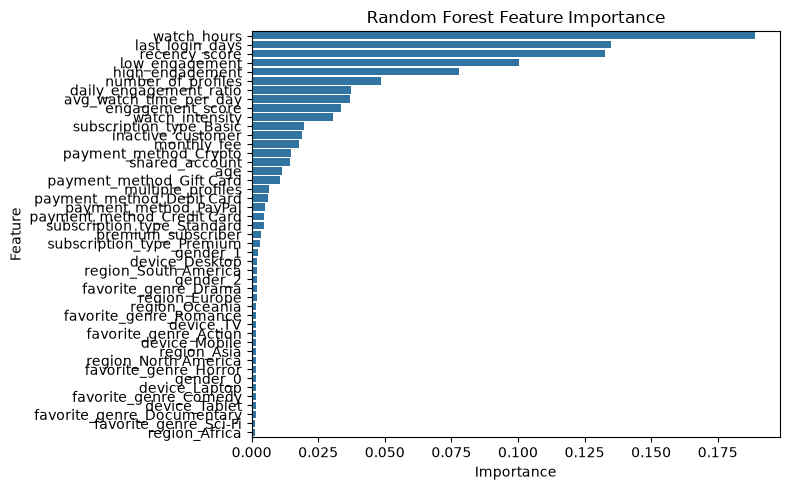

In [15]:
#Visualize Feature Importance

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

The figure displays the feature importance scores generated by the Random Forest model. The chart shows that **Watch Hours**, **Last Login Days**, and **Recency Score** were the most important features used to predict customer churn.
 
The results indicate that customer engagement and platform activity have the strongest influence on churn behaviour. Customers who watch more content and access the platform regularly are less likely to churn, while users with lower engagement levels and longer periods of inactivity are at a higher risk of cancelling their subscriptions.

In [16]:
df.to_csv('Model2.csv', index=False)

This command exports the final dataset, including all preprocessing and feature engineering changes, into a file named Model2.csv. The index=False parameter ensures that the row numbers are not included in the exported file.